**Download the Titanic dataset**

In [ ]:
!pip install opendatasets --quiet
import opendatasets as od

od.download("https://www.kaggle.com/datasets/heptapod/titanic")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: anirbangarai
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/heptapod/titanic


100%|██████████| 10.8k/10.8k [00:00<00:00, 8.07MB/s]

**Import libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

**Load the CSV files**

In [ ]:
!ls -R /content/titanic

titanic_df = pd.read_csv("/content/titanic/train_and_test2.csv")

print("Titanic DataFrame shape:", titanic_df.shape)

titanic_df.head()

/content/titanic:
train_and_test2.csv
Titanic DataFrame shape: (1309, 28)


,Passengerid,Age,Fare,Sex,sibsp,zero,zero.1,zero.2,zero.3,zero.4,...,zero.12,zero.13,zero.14,Pclass,zero.15,zero.16,Embarked,zero.17,zero.18,2urvived
0,1,22.0,7.2500,0,1,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0
1,2,38.0,71.2833,1,1,0,0,0,0,0,...,0,0,0,1,0,0,0.0,0,0,1
2,3,26.0,7.9250,1,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,1
3,4,35.0,53.1000,1,1,0,0,0,0,0,...,0,0,0,1,0,0,2.0,0,0,1
4,5,35.0,8.0500,0,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0


**Inspect the data**

In [ ]:
titanic_df.info()
titanic_df.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 28 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Passengerid  1309 non-null   int64  
 1   Age          1309 non-null   float64
 2   Fare         1309 non-null   float64
 3   Sex          1309 non-null   int64  
 4   sibsp        1309 non-null   int64  
 5   zero         1309 non-null   int64  
 6   zero.1       1309 non-null   int64  
 7   zero.2       1309 non-null   int64  
 8   zero.3       1309 non-null   int64  
 9   zero.4       1309 non-null   int64  
 10  zero.5       1309 non-null   int64  
 11  zero.6       1309 non-null   int64  
 12  Parch        1309 non-null   int64  
 13  zero.7       1309 non-null   int64  
 14  zero.8       1309 non-null   int64  
 15  zero.9       1309 non-null   int64  
 16  zero.10      1309 non-null   int64  
 17  zero.11      1309 non-null   int64  
 18  zero.12      1309 non-null   int64  
 19  zero.1

,Passengerid,Age,Fare,Sex,sibsp,zero,zero.1,zero.2,zero.3,zero.4,...,zero.12,zero.13,zero.14,Pclass,zero.15,zero.16,Embarked,zero.17,zero.18,2urvived
count,1309.000000,1309.000000,1309.000000,1309.000000,1309.000000,1309.0,1309.0,1309.0,1309.0,1309.0,...,1309.0,1309.0,1309.0,1309.000000,1309.0,1309.0,1307.000000,1309.0,1309.0,1309.000000
mean,655.000000,29.503186,33.281086,0.355997,0.498854,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,2.294882,0.0,0.0,1.492731,0.0,0.0,0.261268
std,378.020061,12.905241,51.741500,0.478997,1.041658,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.837836,0.0,0.0,0.814626,0.0,0.0,0.439494
min,1.000000,0.170000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.000000,0.0,0.0,0.000000,0.0,0.0,0.000000
25%,328.000000,22.000000,7.895800,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,2.000000,0.0,0.0,1.000000,0.0,0.0,0.000000
50%,655.000000,28.000000,14.454200,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,3.000000,0.0,0.0,2.000000,0.0,0.0,0.000000
75%,982.000000,35.000000,31.275000,1.000000,1.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,3.000000,0.0,0.0,2.000000,0.0,0.0,1.000000
max,1309.000000,80.000000,512.329200,1.000000,8.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,3.000000,0.0,0.0,2.000000,0.0,0.0,1.000000


**Missing value check**

In [ ]:
missing = titanic_df.isnull().sum().sort_values(ascending=False)
missing_perc = (missing / len(titanic_df) * 100).round(2)
pd.DataFrame({"Missing Count": missing, "Missing %": missing_perc})

,Missing Count,Missing %
Embarked,2,0.15
Passengerid,0,0.00
Fare,0,0.00
Age,0,0.00
sibsp,0,0.00
zero,0,0.00
zero.1,0,0.00
zero.2,0,0.00
zero.3,0,0.00
zero.4,0,0.00


**Data Cleaning**

In [ ]:
titanic_df[titanic_df["Embarked"].isna()]

,Passengerid,Age,Fare,Sex,sibsp,zero,zero.1,zero.2,zero.3,zero.4,...,zero.12,zero.13,zero.14,Pclass,zero.15,zero.16,Embarked,zero.17,zero.18,2urvived
61,62,38.0,80.0,1,0,0,0,0,0,0,...,0,0,0,1,0,0,NaN,0,0,1
829,830,62.0,80.0,1,0,0,0,0,0,0,...,0,0,0,1,0,0,NaN,0,0,1


**Target (Survived) distribution**

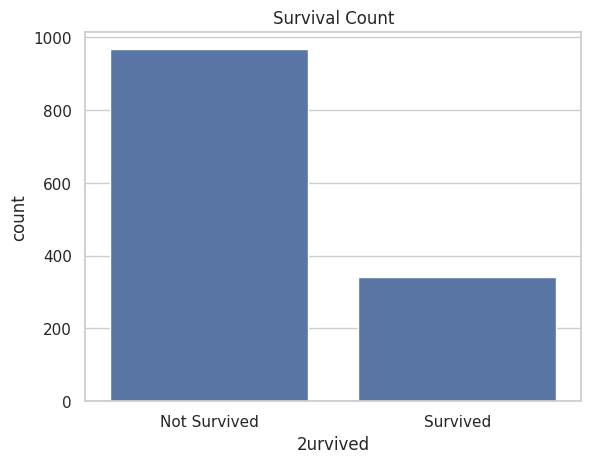

,proportion
2urvived,
0,0.74
1,0.26


In [ ]:
sns.countplot(x="2urvived", data=titanic_df)
plt.title("Survival Count")
plt.xticks([0,1], ["Not Survived", "Survived"])
plt.show()

titanic_df["2urvived"].value_counts(normalize=True).round(2)

**Univariate Analysis**

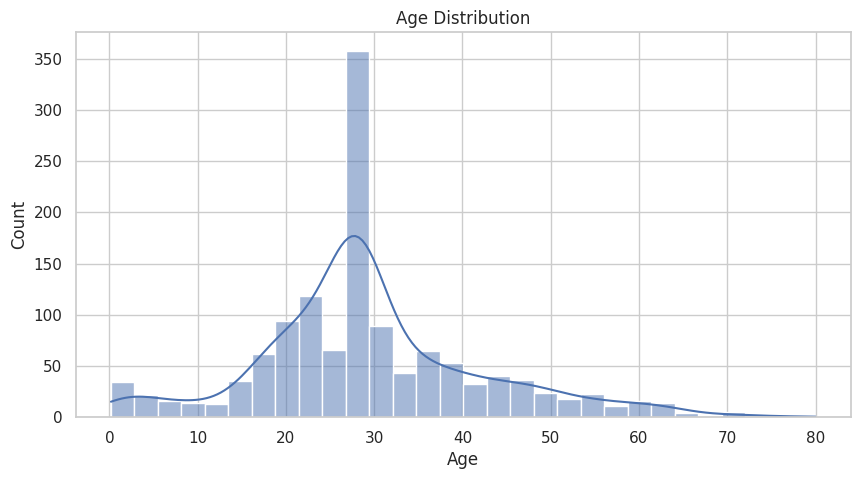

In [ ]:
# Age Distribution

plt.figure(figsize=(10,5))
sns.histplot(titanic_df["Age"].dropna(), bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

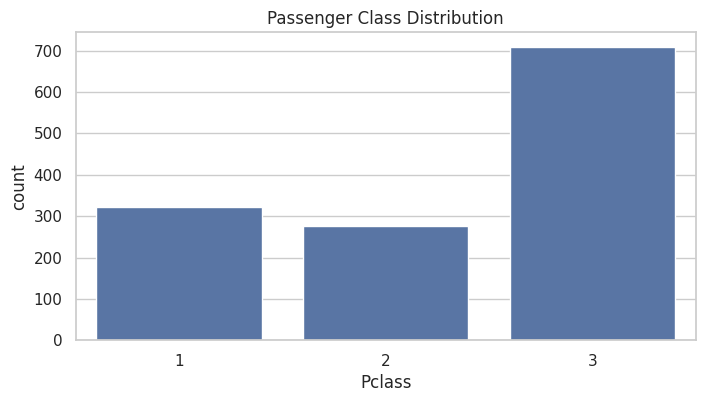

In [ ]:
# Passenger Class

plt.figure(figsize=(8,4))
sns.countplot(x="Pclass", data=titanic_df)
plt.title("Passenger Class Distribution")
plt.show()

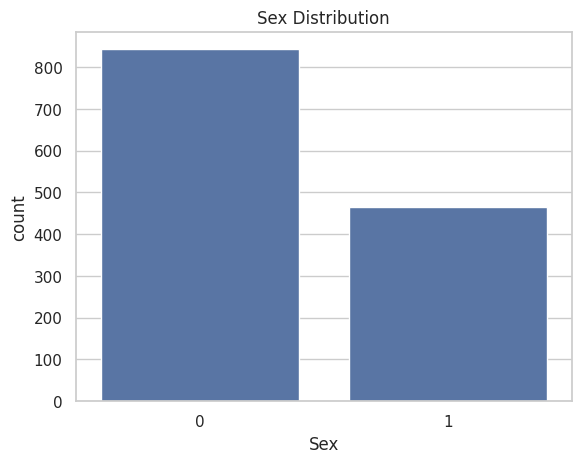

In [ ]:
# Sex Distribution

sns.countplot(x="Sex", data=titanic_df)
plt.title("Sex Distribution")
plt.show()

**Bivariate Analysis**

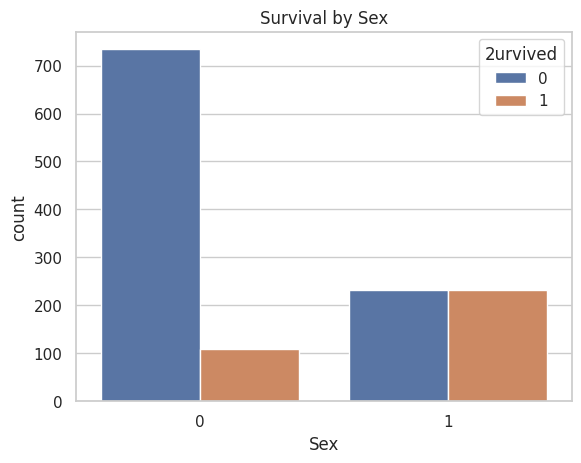

In [ ]:
# Survival vs Sex

sns.countplot(x="Sex", hue="2urvived", data=titanic_df)
plt.title("Survival by Sex")
plt.show()

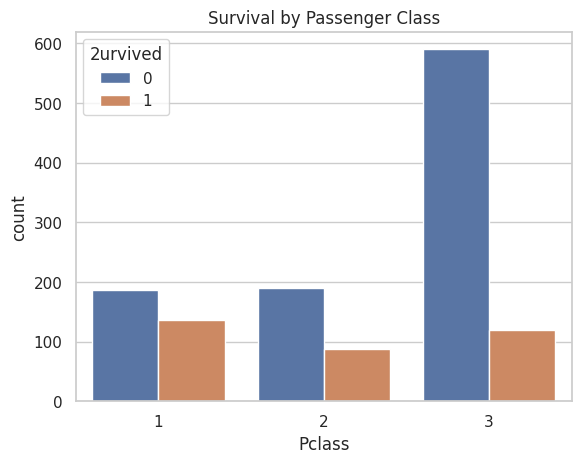

In [ ]:
# Survival vs Passenger Class (Pclass)

sns.countplot(x="Pclass", hue="2urvived", data=titanic_df)
plt.title("Survival by Passenger Class")
plt.show()

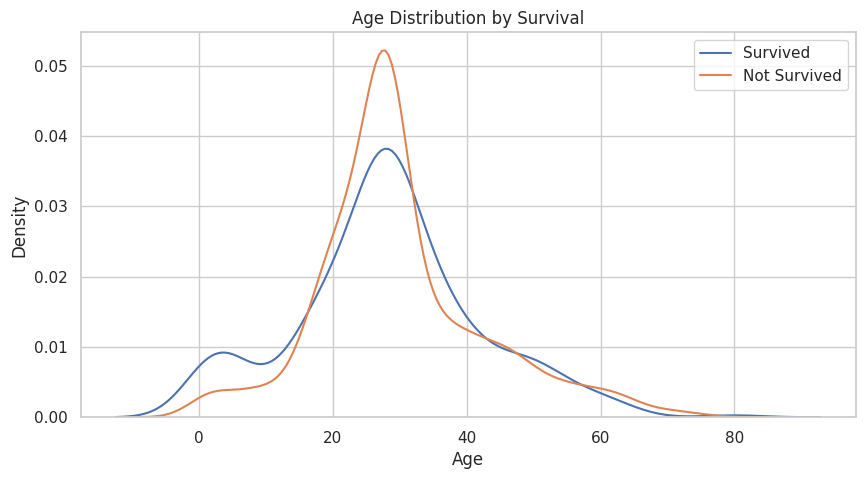

In [ ]:
# Survival vs Age

plt.figure(figsize=(10,5))
sns.kdeplot(titanic_df[titanic_df["2urvived"] == 1]["Age"].dropna(), label="Survived")
sns.kdeplot(titanic_df[titanic_df["2urvived"] == 0]["Age"].dropna(), label="Not Survived")
plt.title("Age Distribution by Survival")
plt.legend()
plt.show()

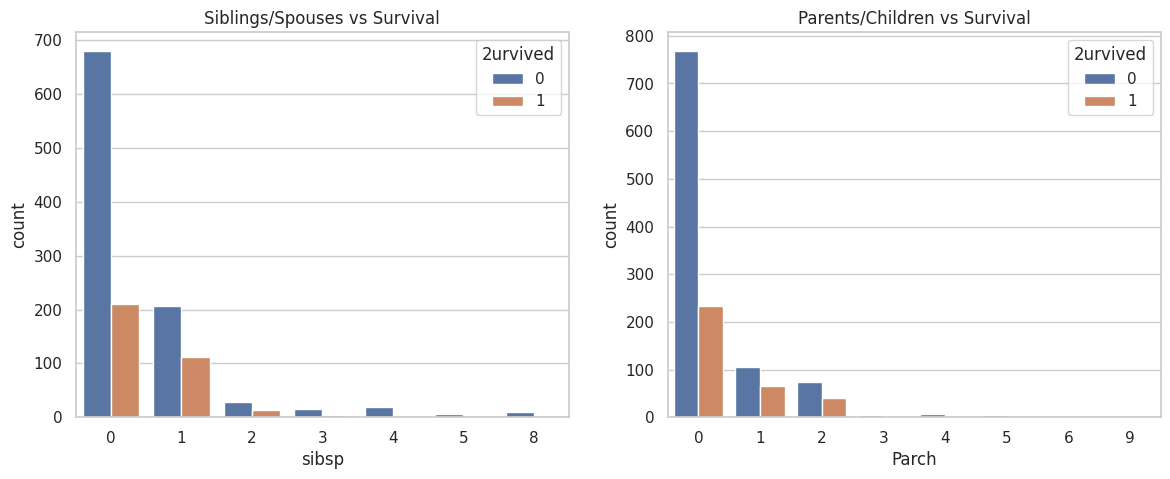

In [ ]:
# Survival vs Family (SibSp & Parch)

fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.countplot(x="sibsp", hue="2urvived", data=titanic_df, ax=axes[0])
axes[0].set_title("Siblings/Spouses vs Survival")

sns.countplot(x="Parch", hue="2urvived", data=titanic_df, ax=axes[1])
axes[1].set_title("Parents/Children vs Survival")

plt.show()

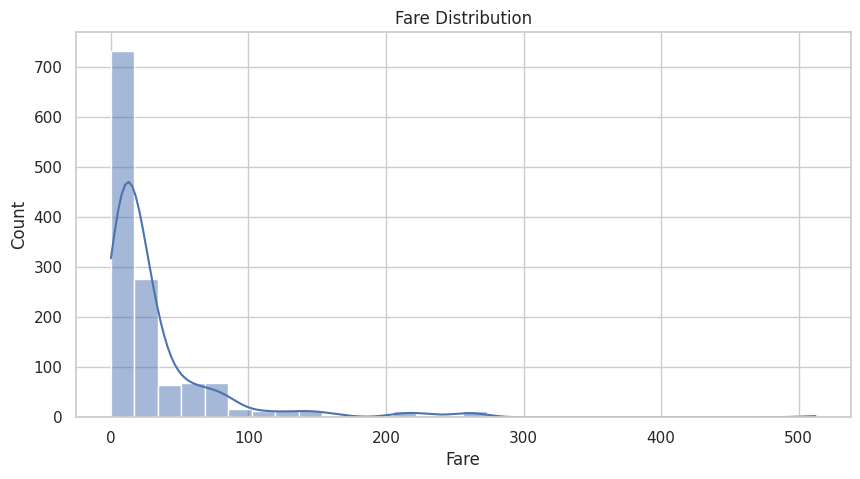

In [ ]:
# Fare Distribution

plt.figure(figsize=(10,5))
sns.histplot(titanic_df["Fare"], bins=30, kde=True)
plt.title("Fare Distribution")
plt.show()

**Correlation Matrix**

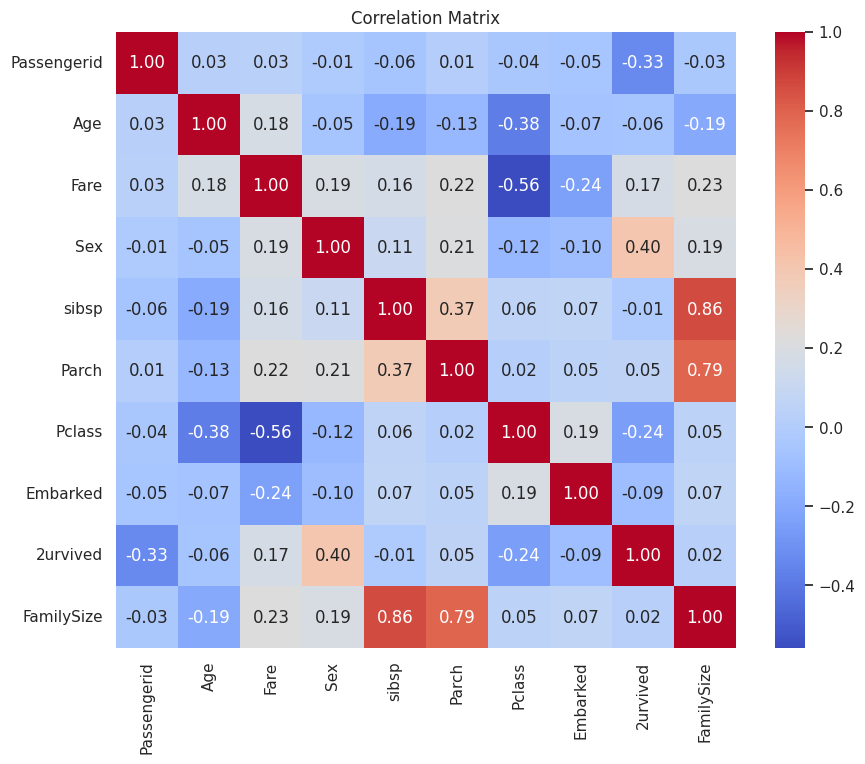

In [ ]:
# Drop columns with only zero values as they don't add value to correlation
zero_cols = [col for col in titanic_df.columns if col.startswith('zero')]
titanic_df_cleaned = titanic_df.drop(columns=zero_cols)

num_cols = titanic_df_cleaned.select_dtypes(include=["int64", "float64"]).columns
corr = titanic_df_cleaned[num_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

**Family Size Analysis**

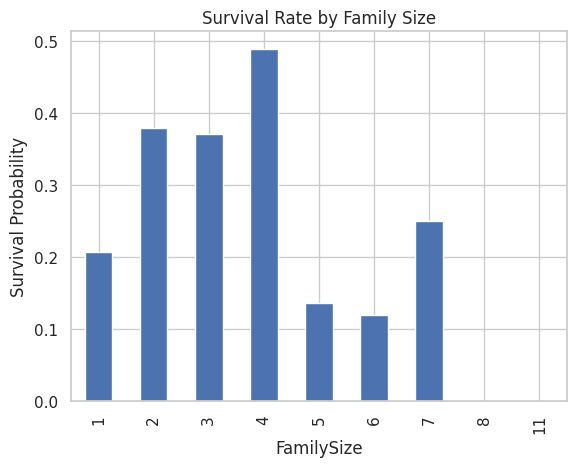

In [ ]:
titanic_df["FamilySize"] = titanic_df["sibsp"] + titanic_df["Parch"] + 1
titanic_df.groupby("FamilySize")["2urvived"].mean().plot(kind="bar")
plt.title("Survival Rate by Family Size")
plt.ylabel("Survival Probability")
plt.show()